*HOG with 128x128 img for feature extraction*

In [62]:
import os
import numpy as np 
from skimage.io import imread
from skimage.transform import resize
from skimage.feature import hog # Histogram Oriented Gradient

dataset_path = "PI_dataset"
features = [] # for storing features of images
labels =[] # for storing labels of images

for label in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, label) 
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = imread(img_path, as_gray=True) # gray img
        img = resize(img,(128,128)) # 128x128 pixels img as output

        hog_feature = hog(img, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2)) # calculation of "Histogram Oriented Gradient" embeddings
        features.append(hog_feature) # embeddings of images, output will be (num of images, dimensional vector)
        labels.append(label) # label of images

X = np.array(features) # numpy features
labels = np.array(labels) # numpy labels


*PCA for Dimensionality Reduction*

In [65]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler # for normalization
pca = PCA(n_components=25) # now each image is represented as R^25
X_pca = pca.fit_transform(X)
X_pca = StandardScaler().fit_transform(X_pca)


*Clustring Algorithm K-Means*

In [72]:
"""
The Pipeline
X_pca -> K-Means -> t-SNE -> Visualization
PCA removes the noise and reduce dimension
K-Means for grouping similar items (unsupervised learning)
t-SNE helps structring 2D, 3D
matplotlib uses in plotting
"""

from sklearn.cluster import KMeans
n=5 # dataset has 5 items
kmeans = KMeans(n_clusters=n,random_state=42, n_init=20 )
cluster_labels_kmeans = kmeans.fit_predict(X_pca)
# print(cluster_labels) # each image has a cluster id

*Applying t-SNE 2D*

In [78]:
"""
Adopting t-SNE method from "Visualizing Data using t-SNE" (https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf)
"""
"""
t-SNE: t-Distributed Stochastic Neighbor Embedding
A nonlinear dimensionality reduction method used to visualize high dimensional data in 2D and 3D

"""

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=5, learning_rate='auto', random_state=42, max_iter=5000, init='pca') # n_components: each img has 2 components (x,y), which will be used for 2D plot
X_tsne_2D = tsne.fit_transform(X_pca)
# print(X_tsne_2D) 

*K-Means and True label comparision plot*

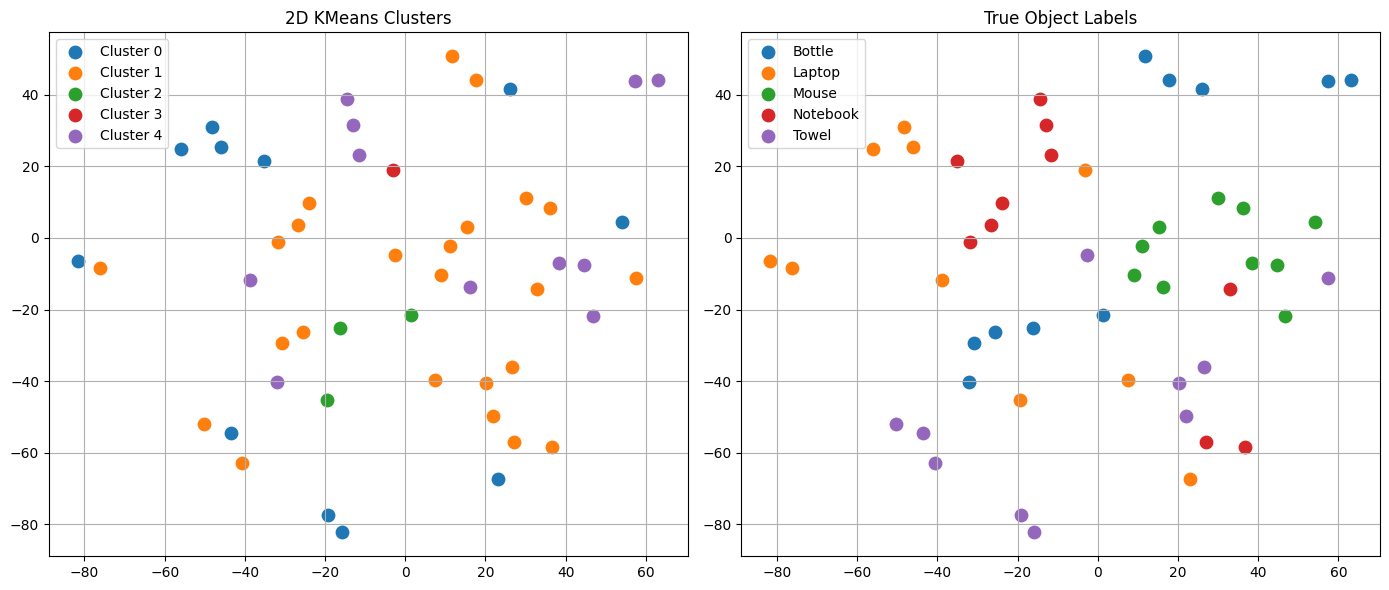

In [80]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means clustring
for c in np.unique(cluster_labels_kmeans):
    idx = cluster_labels_kmeans == c
    axes[0].scatter(
        X_tsne_2D[idx, 0],
        X_tsne_2D[idx, 1],
        s=80,
        label=f"Cluster {c}"
    )

axes[0].set_title("2D KMeans Clusters")
axes[0].grid(True)
axes[0].legend()


# True Labels
unique_labels = np.unique(labels)

for label in unique_labels:
    idx = labels == label
    axes[1].scatter(
        X_tsne_2D[idx, 0],
        X_tsne_2D[idx, 1],
        s=80,
        label=label
    )

axes[1].set_title("True Object Labels")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


*Clustring algorithm DBSCAN*

In [84]:
import numpy as np
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=5,       # neighborhood radius
    min_samples=3  # minimum points to form a cluster
)
cluster_labels_dbscan = dbscan.fit_predict(X_pca)

# checking the number of clusters found
n_clusters = len(set(cluster_labels_dbscan)) - (1 if -1 in cluster_labels_dbscan else 0)
print("Clusters found:", n_clusters)


Clusters found: 2


*Visualization of DBSCAN*

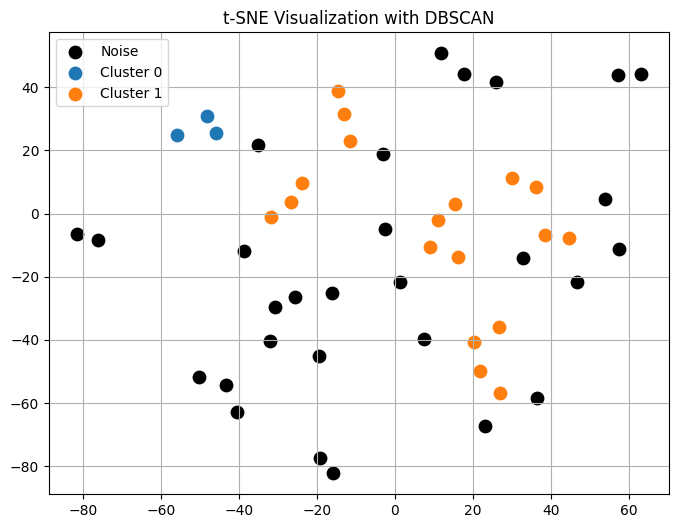

In [85]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

for c in np.unique(cluster_labels_dbscan):

    idx = cluster_labels_dbscan == c

    if c == -1:
        label = "Noise"
        color = "black"
    else:
        label = f"Cluster {c}"
        color = None

    plt.scatter(
        X_tsne_2D[idx, 0],
        X_tsne_2D[idx, 1],
        s=80,
        label=label,
        c=color
    )

plt.title("t-SNE Visualization with DBSCAN")
plt.legend()
plt.grid(True)

plt.show()
